In [ ]:
%pip install kagglehub seaborn

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

full_file_path = f"{path}/adult.csv"

df_raw = pd.read_csv(full_file_path, encoding='latin1', on_bad_lines='skip')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'Dataset shape: {df_raw.shape}')
df_raw.head()

100%|██████████| 652k/652k [00:00<00:00, 16.3MB/s]


Extracting files...
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Split BEFORE any processing — test data is never touched during EDA/cleaning
df_train, df_test = train_test_split(df_raw, test_size=0.30, random_state=42, stratify=df_raw['income'])

print(f'Training set size : {df_train.shape[0]:,} rows ({df_train.shape[0]/len(df_raw)*100:.1f}%)')
print(f'Testing  set size : {df_test.shape[0]:,} rows ({df_test.shape[0]/len(df_raw)*100:.1f}%)')

# Save test set aside — untouched
df_test_untouched = df_test.copy()
print('\nClass distribution in training set:')
print(df_train['income'].value_counts(normalize=True).round(3))

Training set size : 34,189 rows (70.0%)
Testing  set size : 14,653 rows (30.0%)

Class distribution in training set:
income
<=50K   0.76
>50K    0.24
Name: proportion, dtype: float64


In [ ]:
print('=== Training Set Overview ===')
print(f'Shape: {df_train.shape}')
print(f'\nData types:\n{df_train.dtypes}')
print(f'\nBasic statistics:')
df_train.describe()

=== Training Set Overview ===
Shape: (34189, 15)

Data types:
age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object

Basic statistics:


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,34189.00,34189.00,34189.00,34189.00,34189.00,34189.00
mean,38.71,189651.77,10.08,1050.98,89.10,40.48
std,13.71,104982.75,2.57,7281.75,406.10,12.43
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117789.00,9.00,0.00,0.00,40.00
50%,37.00,178282.00,10.00,0.00,0.00,40.00
75%,48.00,237433.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [ ]:
# Identify disguised missing values ('?')
print('=== Missing / ? Values in Training Set ===')
df_train_copy = df_train.copy()
df_train_copy.replace('?', np.nan, inplace=True)

missing = df_train_copy.isnull().sum()
missing_pct = (df_train_copy.isnull().sum() / len(df_train_copy) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

=== Missing / ? Values in Training Set ===
                Missing Count  Missing %
workclass                1926       5.63
occupation               1936       5.66
native-country            590       1.73


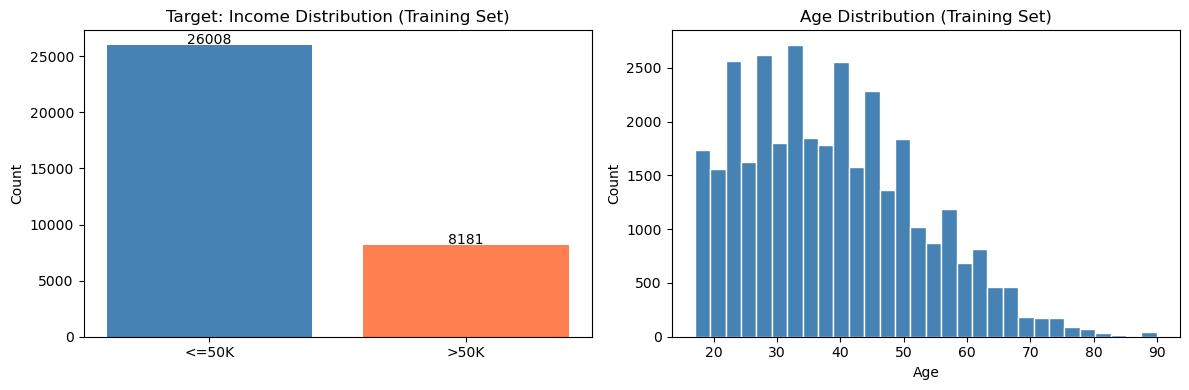

Chart saved.


In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

income_counts = df_train['income'].value_counts()
axes[0].bar(income_counts.index, income_counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Target: Income Distribution (Training Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(income_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center')

# Age distribution
axes[1].hist(df_train['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution (Training Set)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved.')

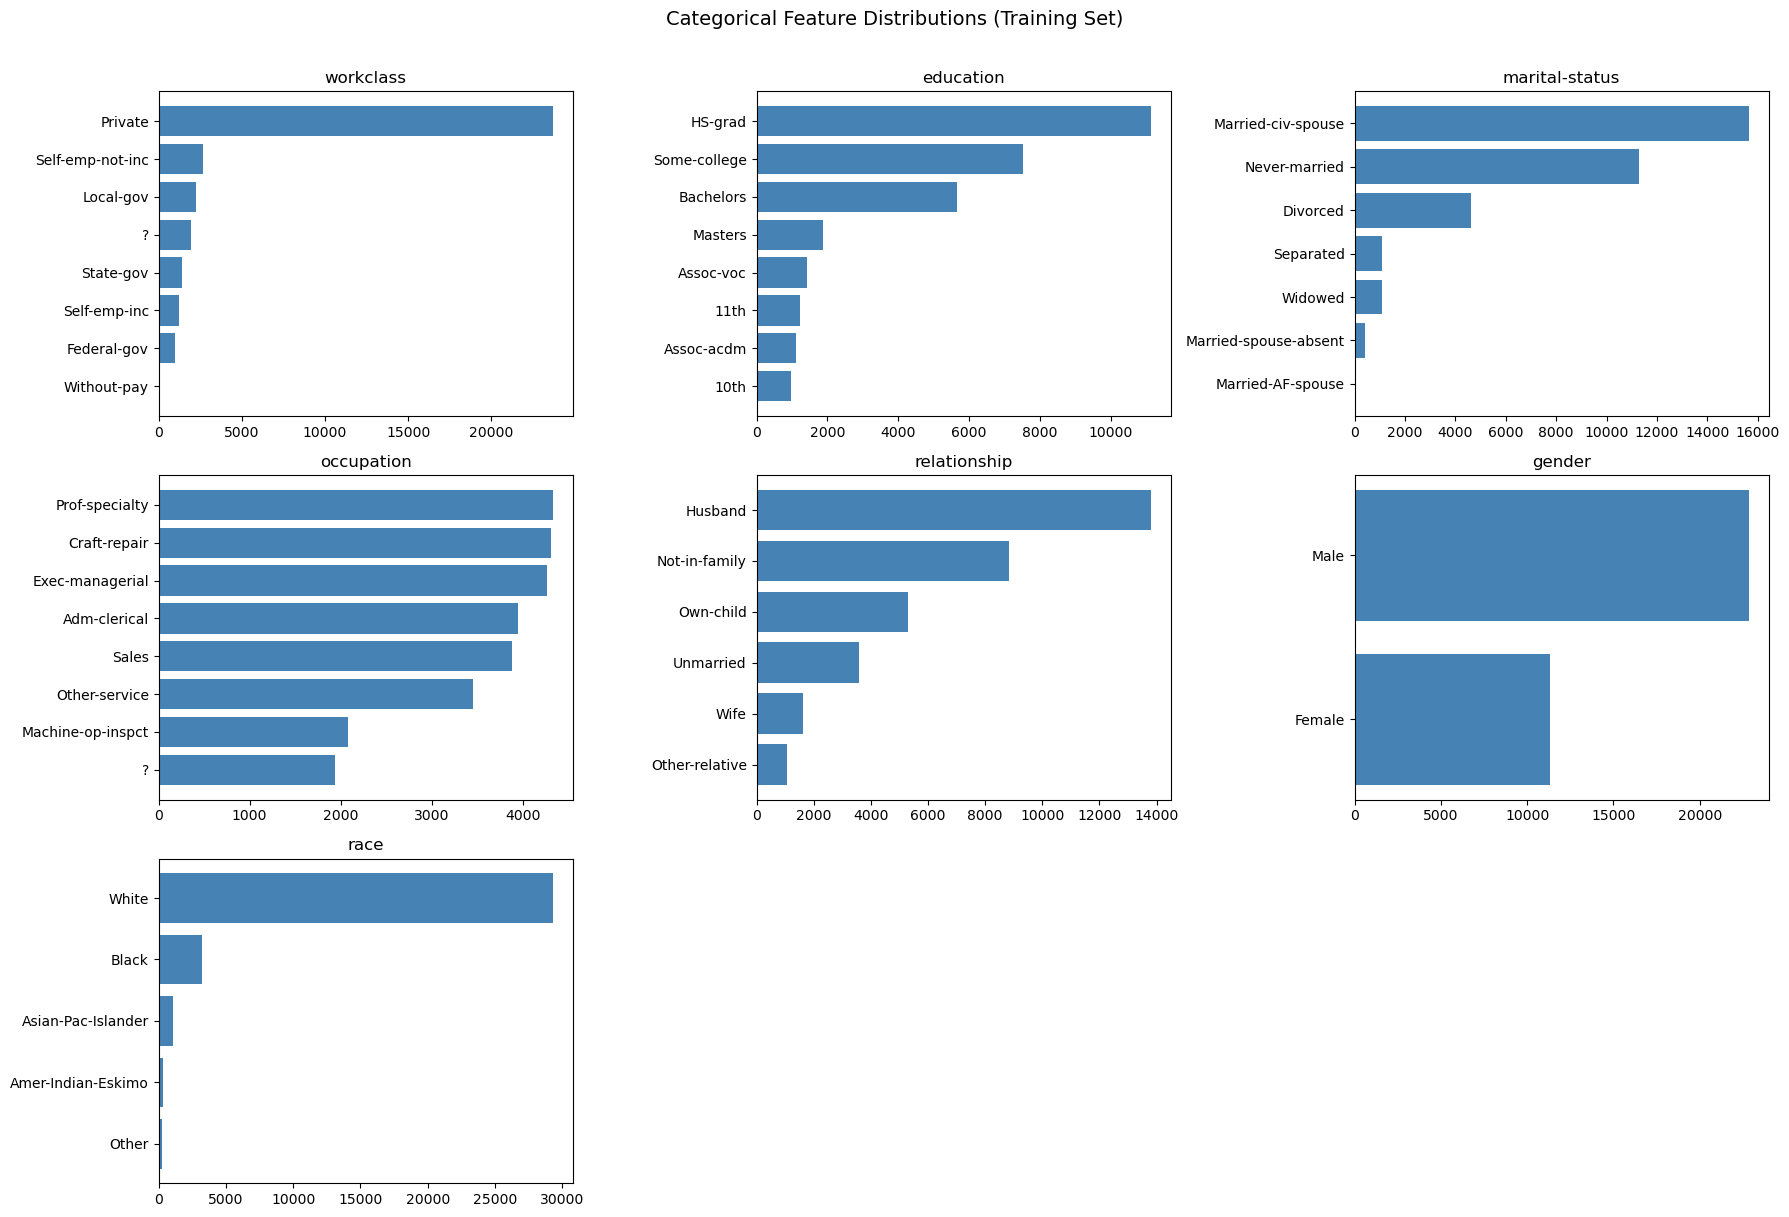

In [ ]:
# Categorical feature exploration
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'gender', 'race']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_train[col].value_counts().head(8)
    axes[i].barh(counts.index, counts.values, color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].invert_yaxis()

# Hide unused subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions (Training Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=100, bbox_inches='tight')
plt.show()

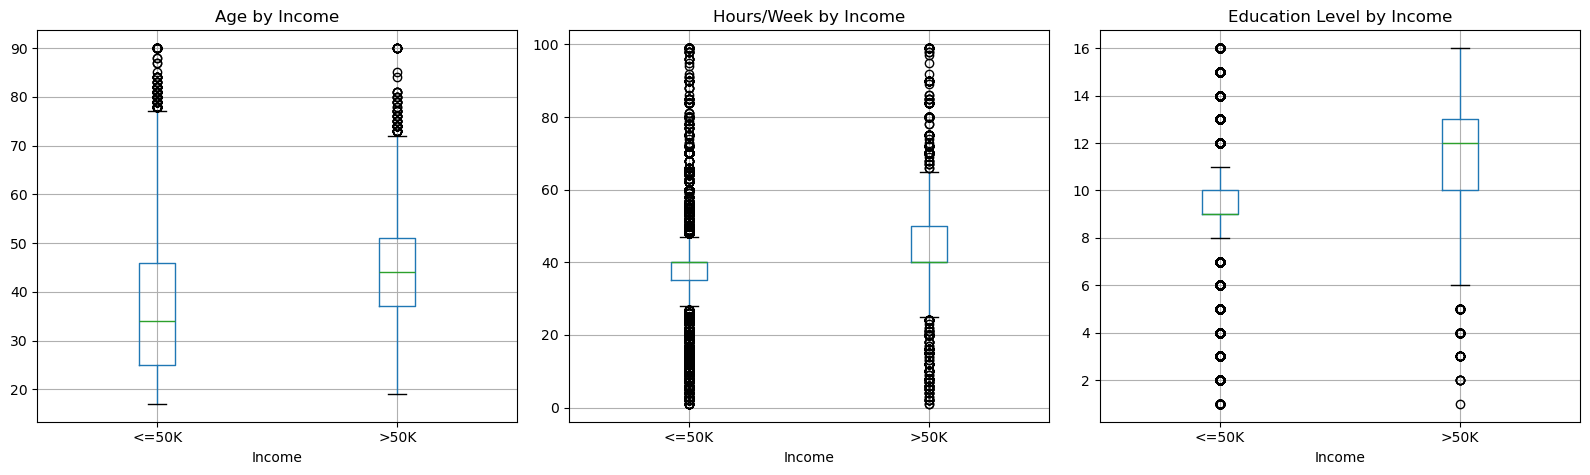

In [ ]:
# Income by key features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age by income
df_train.boxplot(column='age', by='income', ax=axes[0])
axes[0].set_title('Age by Income')
axes[0].set_xlabel('Income')

# Hours per week by income
df_train.boxplot(column='hours-per-week', by='income', ax=axes[1])
axes[1].set_title('Hours/Week by Income')
axes[1].set_xlabel('Income')

# Education num by income
df_train.boxplot(column='educational-num', by='income', ax=axes[2])
axes[2].set_title('Education Level by Income')
axes[2].set_xlabel('Income')

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_income_features.png', dpi=100, bbox_inches='tight')
plt.show()

**Data Cleaning**

**Missing values**

Three categorical columns, "workclass," "occupation," and "native-country," contain missing values. The raw dataset has set the missing values as "?".

To add values to the missing data, we will carry out the following steps:
1. Make a new copy to preserve the original dataset
2. Replace all "?" strings with "NaN" missing values
3. Calculate the mode for each column
4. Replace the NaN with the mode

In [ ]:
# Data cleaning on copy of training data
df_clean = df_train.copy()

print('=== BEFORE Cleaning ===')
print('Sample rows with ? values:')
print(df_clean[df_clean['workclass'] == '?'][['age','workclass','occupation','native-country','income']].head(5))

# Replace '?' with NaN
df_clean.replace('?', np.nan, inplace=True)

# Fill NaN with mode from training set
cols_with_missing = ['workclass', 'occupation', 'native-country']
fill_values = {}
for col in cols_with_missing:
    mode_val = df_clean[col].mode()[0]
    fill_values[col] = mode_val
    df_clean[col].fillna(mode_val, inplace=True)
    print(f'Filled "{col}" NaN with mode: "{mode_val}"')

=== BEFORE Cleaning ===
Sample rows with ? values:
       age workclass occupation native-country income
17212   19         ?          ?  United-States  <=50K
9312    32         ?          ?  United-States  <=50K
12616   47         ?          ?  United-States  <=50K
2547    51         ?          ?          South  <=50K
27636   73         ?          ?  United-States  <=50K
Filled "workclass" NaN with mode: "Private"
Filled "occupation" NaN with mode: "Prof-specialty"
Filled "native-country" NaN with mode: "United-States"


In [ ]:
print('=== AFTER Cleaning — No More ? / NaN ===')
print(df_clean[['workclass','occupation','native-country']].isnull().sum())
print()
print('workclass value counts (? gone):')
print(df_clean['workclass'].value_counts())

=== AFTER Cleaning — No More ? / NaN ===
workclass         0
occupation        0
native-country    0
dtype: int64

workclass value counts (? gone):
workclass
Private             25635
Self-emp-not-inc     2681
Local-gov            2239
State-gov            1383
Self-emp-inc         1209
Federal-gov          1016
Without-pay            16
Never-worked           10
Name: count, dtype: int64


It confirms that there aren't any more missing values in the columns. As an example, we can see that in the column "workclass," all the NaN values are reassigned to Private.

**Scaling**

Different columns have varying numerical values. The column "age" spans from 17 to 90, whereas the column "fnlwgt" exceeds a million. Scaling the numerical data rescales the values between the [0, 1] range so that no column dominates the others.

In [ ]:
numeric_cols = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print('=== BEFORE Scaling ===')
print(df_clean[numeric_cols].describe().loc[['min','max','mean']])

# Apply MinMax scaling
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])

print('\n=== AFTER Min-Max Scaling (range now 0 to 1) ===')
print(df_scaled[numeric_cols].describe().loc[['min','max','mean']])

=== BEFORE Scaling ===
       age     fnlwgt  educational-num  capital-gain  capital-loss  \
min  17.00   12285.00             1.00          0.00          0.00   
max  90.00 1484705.00            16.00      99999.00       4356.00   
mean 38.71  189651.77            10.08       1050.98         89.10   

      hours-per-week  
min             1.00  
max            99.00  
mean           40.48  

=== AFTER Min-Max Scaling (range now 0 to 1) ===
      age  fnlwgt  educational-num  capital-gain  capital-loss  hours-per-week
min  0.00    0.00             0.00          0.00          0.00            0.00
max  1.00    1.00             1.00          1.00          1.00            1.00
mean 0.30    0.12             0.61          0.01          0.02            0.40


The numerical columns "age," "fnlwgt," "educational-num," "capital-gain," "capital-loss," and "hours-per-week" now have values between 0 and 1, so each column has equal weight.

**Normalization**

The columns "capital-gain," "capital-loss," and "fnlwgt" are significantly skewed to the right. The majority of the data has a value of zero, while just a few have really significant values. Z-score normalization modifies data with a mean of 0 and a standard deviation of 1. This draws the outliers into the center.

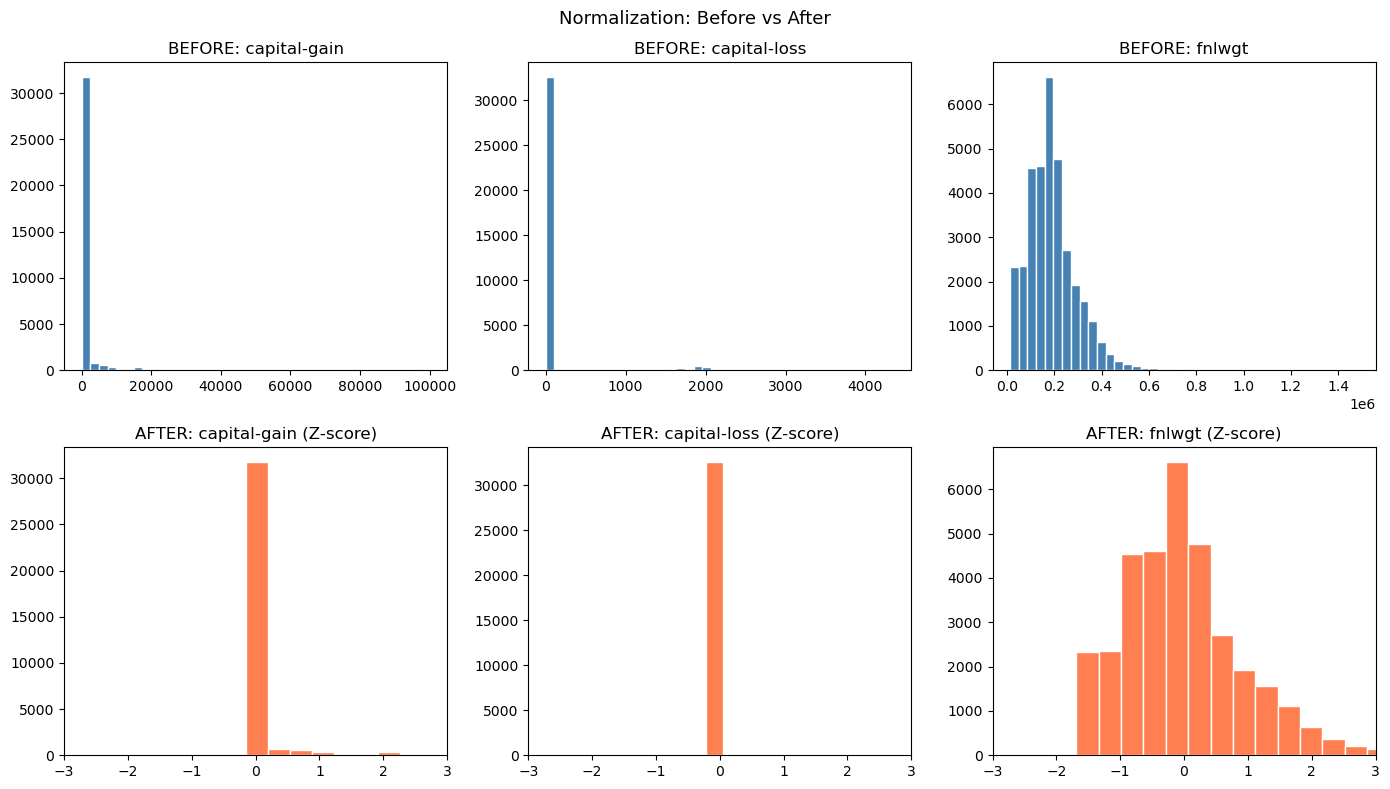

Mean after normalization (should be ~0):
capital-gain   -0.00
capital-loss   -0.00
fnlwgt         -0.00
dtype: float64
Std after normalization (should be ~1):
capital-gain   1.00
capital-loss   1.00
fnlwgt         1.00
dtype: float64


In [ ]:
# Histogram BEFORE normalization
skewed_cols = ['capital-gain', 'capital-loss', 'fnlwgt']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df_clean[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'BEFORE: {col}')

# Apply StandardScaler (Z-score normalization)
std_scaler = StandardScaler()
df_normalized = df_scaled.copy()
df_normalized[skewed_cols] = std_scaler.fit_transform(df_clean[skewed_cols])

#Histogram AFTER normalization
for i, col in enumerate(skewed_cols):
    axes[1, i].hist(df_normalized[col], bins=40, color='coral', edgecolor='white')
    axes[1, i].set_title(f'AFTER: {col} (Z-score)')
    axes[1, i].set_xlim(-3, 3)

plt.suptitle('Normalization: Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Mean after normalization (should be ~0):')
print(df_normalized[skewed_cols].mean().round(4))
print('Std after normalization (should be ~1):')
print(df_normalized[skewed_cols].std().round(4))

The first 3 histograms show that the data in the columns are skewed to the right. After normalization, the distribution has recentered around 0 and has a more balanced spread.

In [ ]:
df_encoded = df_normalized.copy()

print('=== BEFORE Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

# Label encode binary columns
le = LabelEncoder()
binary_cols = ['gender', 'income']
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col} mapping: {mapping}')

print('\n=== AFTER Label Encoding ===')
print(df_encoded[['gender', 'income']].head(5))

In [ ]:
ohe_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']

print(f'=== BEFORE One-Hot Encoding ===')
print(f'Shape: {df_encoded.shape}')
print(df_encoded[ohe_cols].head(3))

# One-Hot Encode
df_ohe = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

print(f'\n=== AFTER One-Hot Encoding ===')
print(f'Shape: {df_ohe.shape} (columns expanded from {df_encoded.shape[1]} to {df_ohe.shape[1]})')
print('New columns added (sample):')
new_cols = [c for c in df_ohe.columns if any(c.startswith(cat) for cat in ohe_cols)]
print(new_cols[:15], '...')

In [ ]:
df_feat = df_ohe.copy()

# NOTE: age and hours-per-week are scaled (0-1). Use original df_clean for engineering then re-scale.
# For clarity, we reconstruct from original training values:
df_feat_check = df_clean.copy()
df_feat_check.replace('?', np.nan, inplace=True)
for col in cols_with_missing:
    df_feat_check[col].fillna(fill_values[col], inplace=True)

# Feature 1: capital_net = capital.gain - capital.loss
df_feat['capital_net'] = df_feat_check['capital-gain'] - df_feat_check['capital-loss']
print('Feature 1 — capital_net (capital gain minus capital loss):')
print(df_feat['capital_net'].describe())

# Feature 2: age_group — bin age into life stages
df_feat['age_group'] = pd.cut(
    df_feat_check['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['Young', 'EarlyCareer', 'MidCareer', 'LateCareer', 'Senior']
)
df_feat['age_group'] = LabelEncoder().fit_transform(df_feat['age_group'].astype(str))
print('\nFeature 2 — age_group value counts:')
print(df_feat['age_group'].value_counts())

# Feature 3: is_high_hours — binary flag for people working more than 45 hrs/week
df_feat['is_high_hours'] = (df_feat_check['hours-per-week'] > 45).astype(int)
print('\nFeature 3 — is_high_hours (>45 hrs/week):')
print(df_feat['is_high_hours'].value_counts())

print(f'\nFinal dataset shape after feature engineering: {df_feat.shape}')

In [ ]:
summary = {
    'Stage': [
        'Raw Dataset',
        'After Train/Test Split (train)',
        'After Cleaning (? -> mode)',
        'After Scaling (MinMax)',
        'After Normalization (Z-score)',
        'After Label Encoding',
        'After One-Hot Encoding',
        'After Feature Engineering'
    ],
    'Rows': [
        df_raw.shape[0],
        df_train.shape[0],
        df_clean.shape[0],
        df_scaled.shape[0],
        df_normalized.shape[0],
        df_encoded.shape[0],
        df_ohe.shape[0],
        df_feat.shape[0]
    ],
    'Columns': [
        df_raw.shape[1],
        df_train.shape[1],
        df_clean.shape[1],
        df_scaled.shape[1],
        df_normalized.shape[1],
        df_encoded.shape[1],
        df_ohe.shape[1],
        df_feat.shape[1]
    ],
    'Missing Values': [
        df_raw.replace('?', np.nan).isnull().sum().sum(),
        df_train.replace('?', np.nan).isnull().sum().sum(),
        df_clean.isnull().sum().sum(),
        df_scaled.isnull().sum().sum(),
        df_normalized.isnull().sum().sum(),
        df_encoded.isnull().sum().sum(),
        df_ohe.isnull().sum().sum(),
        df_feat.isnull().sum().sum()
    ]
}

summary_df = pd.DataFrame(summary)
print('=== Dataset Transformation Summary ===')
print(summary_df.to_string(index=False))

In [ ]:
# Visual comparison: age column before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Before scaling
axes[0].hist(df_clean['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age - Raw (Training)')
axes[0].set_xlabel('Age')

# After MinMax scaling
axes[1].hist(df_scaled['age'], bins=30, color='green', edgecolor='white')
axes[1].set_title('Age - After MinMax Scaling')
axes[1].set_xlabel('Scaled Value [0,1]')

# Income class balance
income_map = {'<=50K': 0, '>50K': 1}
income_encoded = df_train['income'].map(income_map)
axes[2].bar(['<=50K (0)', '>50K (1)'], income_encoded.value_counts().sort_index().values,
            color=['steelblue', 'coral'])
axes[2].set_title('Target Variable (income) - Encoded')
axes[2].set_ylabel('Count')

plt.suptitle('Before vs After Transformations', fontsize=13)
plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(df_feat.corr(), cmap='coolwarm', fmt=".2f", annot=False, linewidths=.5)
plt.title('Correlation Matrix of All Processed Features', fontsize=16)
plt.show()


# Calculate correlation matrix
correlation_matrix = df_feat.corr()

# Extract correlations with 'income' and sort them
income_correlations = correlation_matrix['income'].sort_values(ascending=False)

print('\n=== Correlations with Income ===')
print('Top 10 Positive Correlations:')
print(income_correlations.head(10))

print('\nTop 10 Negative Correlations:')
print(income_correlations.tail(10))


In [ ]:
# Export clean training data
df_feat.to_csv('adult_income_clean_train.csv', index=False)
print(f'Clean training dataset saved: adult_income_clean_train.csv')
print(f'Shape: {df_feat.shape}')

# Save untouched test set
df_test_untouched.to_csv('adult_income_test_raw.csv', index=False)
print(f'\nUntouched test dataset saved: adult_income_test_raw.csv')
print(f'Shape: {df_test_untouched.shape}')

print('\nFirst 3 rows of clean training data:')
df_feat.head(3)

##Reflections

 - Alfredo Garza (Label Encoding and One-Hot Encoding): The encoding section required us to make a deliberate choice about which method to apply to which columns rather than just picking one approach for everything. There were two features `sex` and `income` with only 2 unique values. The key judgment call was recognizing these were the only two columns safe for label encoding — applying it to anything with more than 2 categories would imply a false numeric ordering. For One-Hot Encoding, this was applied to 7 columns: `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, and `native.country`. The feature space expanded from 15 columns to roughly 100. We also used `drop_first=True` in `pd.get_dummies()` to remove one redundant dummy column per feature, which prevents multicollinearity in the final feature matrix.